In [1]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

from numpy.polynomial.chebyshev import Chebyshev

from scipy.integrate import nquad, quad
from scipy.optimize import minimize_scalar, root_scalar

In [2]:
# Tasks
# 1) Check for curtis-clenshaw integrator in scipy or numpy
#     Found: scipy.integrate.nquad which has a curtis-clenshaw option
# 2) Check what available precisions we can use (64-bit? 80-bit? 128-bit?)
#     Found: heyoka.py has arbitrary precision integrators

In [3]:
plt.rc('font', size=18)
plt.rc('lines', linewidth=2)
plt.rc('figure', figsize=(8,6))

In [4]:
# List of files, and the angles they correspond to, each in the form ("filename", angle)
# Each file should begin with a line containing the number of data points (or a blank line)
# Each subsequent line should contain two real numbers separated by whitespace:
# the separation in Bohr followed by the potential energy in Hartree.

potential_files_and_angles = [
    ("PC.in.000", 0),   ("PC.in.010", 10),  ("PC.in.020", 20),  ("PC.in.030", 30),
    ("PC.in.040", 40),  ("PC.in.050", 50),  ("PC.in.060", 60),  ("PC.in.070", 70),
    ("PC.in.080", 80),  ("PC.in.090", 90),  ("PC.in.100", 100), ("PC.in.110", 110),
    ("PC.in.120", 120), ("PC.in.130", 130), ("PC.in.140", 140), ("PC.in.150", 150),
    ("PC.in.160", 160), ("PC.in.170", 170), ("PC.in.180", 180)]

# We assume that all potentials fall off as R^(-4) for large separations R
long_range_pow = -4

# Only collisions between these given minimum and maximum energies (in Hartree) will be considered.
minimum_energy = 1e-9
maximum_energy = 1.0

## TO DO: CHECKS ON POTENTIAL:

1) R values must increase monotonically. (Error or warning?)
2) Potential should be approximated well by R^(long_range_pow) for large R values.
3) The first three potential energies (for small R) must all be positive
4) The last three potential energies (for large R) must all be negative
5) The largest given potential energy must equal or exceed e_max. (In this case, don't need to halt. Just change emax.)

In [5]:
# Create lists of the given pairs of values (r, V(r)) indexed by the angle in degrees.
# e.g. given_potentials[10] = [(r_1, V_1), (r_2, V_2) ... ]

given_potentials = {}
for filename, angle in potential_files_and_angles:
    with open(filename, "r") as f:
        # Read file into an array of lines stripped of whitespace.
        lines = [line.strip() for line in f.readlines()]

        # Remove the first line, which should contain the number of values.
        lines = lines[1:]

        given_potentials[angle] = []
        for line in lines:
            distance, energy = [float(x) for x in line.split()]
            given_potentials[angle].append((distance, energy))

In [6]:
given_potentials

{0: [(3.5, 0.180988023249902),
  (3.75, 0.108955988524789),
  (4.0, 0.064279242551971),
  (4.25, 0.03710315743913),
  (4.5, 0.020863420836152),
  (4.75, 0.011332781687058),
  (5.0, 0.005850132734107),
  (5.25, 0.002770090792039),
  (5.5, 0.001091593935905),
  (5.75, 0.000214909650381),
  (6.0, -0.000213461804638),
  (6.25, -0.000398230415131),
  (6.5, -0.00045544901013),
  (6.75, -0.000449363503657),
  (7.0, -0.000414852825105),
  (7.25, -0.000370272868989),
  (7.5, -0.000324638100355),
  (7.75, -0.000282011913207),
  (8.0, -0.000244003106617),
  (8.25, -0.000211131808215),
  (8.5, -0.000183257721451),
  (8.75, -0.000159769721596),
  (9.0, -0.000139927213237),
  (9.25, -0.000123087124381),
  (9.5, -0.000108730988164),
  (9.75, -9.6436555239e-05),
  (10.0, -8.5864299124e-05),
  (10.25, -7.6733107845e-05),
  (10.5, -6.8814920787e-05),
  (10.75, -6.1922763372e-05),
  (11.0, -5.5902111346e-05),
  (11.5, -4.5984839809e-05),
  (12.0, -3.8271486827e-05),
  (13.0, -2.7284061105e-05),
  (14.0, 

In [7]:
# Create lists of the angles given, and the distances and energies, indexed by angle.
angles_given = []
distances_given = {}
energies_given = {}
for angle, potential_values in given_potentials.items():
    angles_given.append(angle)
    distances_given[angle] = [distance for distance, _ in potential_values]
    energies_given[angle] = [energy for _, energy in potential_values]

In [8]:
energies_given[0]

[0.180988023249902,
 0.108955988524789,
 0.064279242551971,
 0.03710315743913,
 0.020863420836152,
 0.011332781687058,
 0.005850132734107,
 0.002770090792039,
 0.001091593935905,
 0.000214909650381,
 -0.000213461804638,
 -0.000398230415131,
 -0.00045544901013,
 -0.000449363503657,
 -0.000414852825105,
 -0.000370272868989,
 -0.000324638100355,
 -0.000282011913207,
 -0.000244003106617,
 -0.000211131808215,
 -0.000183257721451,
 -0.000159769721596,
 -0.000139927213237,
 -0.000123087124381,
 -0.000108730988164,
 -9.6436555239e-05,
 -8.5864299124e-05,
 -7.6733107845e-05,
 -6.8814920787e-05,
 -6.1922763372e-05,
 -5.5902111346e-05,
 -4.5984839809e-05,
 -3.8271486827e-05,
 -2.7284061105e-05,
 -1.998155545e-05,
 -1.4911914313e-05,
 -1.1318984518e-05,
 -6.80479712e-06,
 -4.326502785e-06,
 -2.928817209e-06,
 -2.066266604e-06,
 -1.494301474e-06,
 -1.093482668e-06,
 -8.2023128e-07]

## Plot some of the given potentials

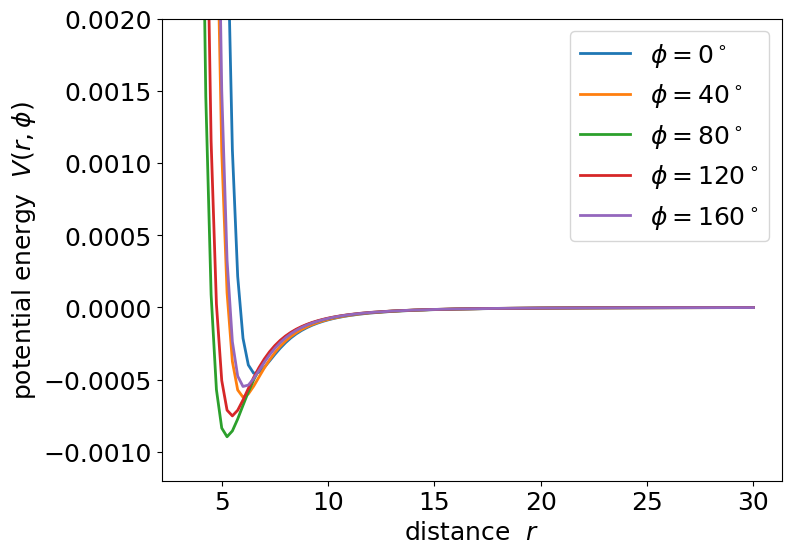

In [9]:
for angle in angles_given[::4]:
    plt.plot(distances_given[angle], energies_given[angle], label=f"$\\phi = {angle}^\\circ$")
plt.xlabel("distance  $r$")
plt.ylabel("potential energy  $V(r, \\phi)$")
plt.ylim((-0.0012, 0.002))
plt.legend();

In [10]:
# We will extrapolate a given potential to arbitrarily small separations by
# fitting the first two points to a power law of the form V(r) = C*R^k where
# C and k are fixed constants.

# This function finds the power k above
def get_short_range_power(distances, energies):
    delta_log_potential = np.log(energies[0]) - np.log(energies[1])
    delta_log_distance = np.log(distances[0]) - np.log(distances[1])
    return delta_log_potential / delta_log_distance

# This function finds the coef C above
def get_short_range_coef(distances, energies):
    power = get_short_range_power(distances, energies)
    return energies[0] / distances[0]**power

In [11]:
# Determine the short range fits (power and coef) for each angle and
# store these in dictionaries indexed by angle
short_range_coefs = {}
short_range_powers = {}
for angle in angles_given:
    distances = distances_given[angle]
    energies = energies_given[angle]
    short_range_coefs[angle] = get_short_range_coef(distances, energies)
    short_range_powers[angle] = get_short_range_power(distances, energies)

In [12]:
# This function creates and returns the extrapolated potential function. For
# separations less than the smallest given, the short range fit is used.
# For separations greater than the largest given, we assume the potential
# fall off as R^(long_range_pow) for large separations R. For separations
# between these extremes, the given potential is fitted to a natural cubic spline.

def create_extrapolated_potential(distances, energies, long_range_pow):
    short_coef = get_short_range_coef(distances, energies)
    short_pow = get_short_range_power(distances, energies)
    short_deriv = short_coef * short_pow * distances[0]**(short_pow - 1)

    # distances[-1] is the last distance in the list (which should be the largest
    # separation.)

    # energies[-1] is the last energy value in the list. This is the energy
    # at the largest separation.
    
    long_coef = energies[-1] / distances[-1]**long_range_pow
    long_deriv = long_coef * long_range_pow * distances[-1]**(long_range_pow - 1)

    # In this next line, bc_type=((1,short_deriv), (1, long_deriv)) forces the
    # derivatives of the cubic spline fit to match the first derivatives of the
    # extrapolations.
    # print(distances, energies)
    mid_range_potential = CubicSpline(
        distances, energies, bc_type=((1, short_deriv), (1, long_deriv)))
    print(mid_range_potential(3.5))

    min_distance_given = min(distances)
    max_distance_given = max(distances)

    # This is the potential function that is returned
    def returned_function(distance):
        if distance < min_distance_given:
            return short_coef * distance ** short_pow
        elif distance > max_distance_given:
            return long_coef * distance ** long_range_pow
        else:
            return float(mid_range_potential(distance))
    return returned_function

In [13]:
# Same idea here as for create_extrapolated_potential, but we create
# the derivative of the potential instead.
def create_derivative_potential(distances, energies, long_range_pow):
    short_coef = get_short_range_coef(distances, energies)
    short_pow = get_short_range_power(distances, energies)
    short_deriv = short_coef * short_pow * distances[0]**(short_pow - 1)
    
    long_coef = energies[-1] / distances[-1]**long_range_pow
    long_deriv = long_coef * long_range_pow * distances[-1]**(long_range_pow - 1)

    # We create the spline fit portion of the potential in the same was as before
    # using natural boundary conditions.
    mid_range_potential = CubicSpline(
        distances, energies, bc_type=((1, short_deriv), (1, long_deriv)))
    
    mid_range_derivative = mid_range_potential.derivative(1)
    
    min_distance_given = min(distances)
    max_distance_given = max(distances)
    
    def returned_function(distance):
        if distance < min_distance_given:
            return short_coef * short_pow * distance ** (short_pow - 1)
        elif distance > max_distance_given:
            return long_coef * long_range_pow * distance ** (long_range_pow - 1)
        else:
            return float(mid_range_derivative(distance))
    return returned_function

In [14]:
# Same idea here as for create_extrapolated_potential, but we create
# the second derivative of the potential instead

def create_second_derivative_potential(distances, energies, long_range_pow):
    short_coef = get_short_range_coef(distances, energies)
    short_pow = get_short_range_power(distances, energies)
    short_deriv = short_coef * short_pow * distances[0]**(short_pow - 1)
    
    long_coef = energies[-1] / distances[-1]**long_range_pow
    long_deriv = long_coef * long_range_pow * distances[-1]**(long_range_pow - 1)

    mid_range_potential = CubicSpline(
        distances, energies, bc_type=((1, short_deriv), (1, long_deriv)))
    mid_range_second_derivative = mid_range_potential.derivative(2)
    
    min_distance_given = min(distances)
    max_distance_given = max(distances)
    
    def returned_function(distance):
        if distance < min_distance_given:
            return short_coef * short_pow * (short_pow - 1) * distance ** (short_pow - 2)
        elif distance > max_distance_given:
            return long_coef * long_range_pow * (long_range_pow - 1) * distance ** (long_range_pow - 2)
        else:
            return float(mid_range_second_derivative(distance))
    return returned_function

In [15]:
angle = 0

vf = create_extrapolated_potential(distances_given[angle], energies_given[angle], long_range_pow)
vd = create_derivative_potential(distances_given[angle], energies_given[angle], long_range_pow)
vd2 = create_second_derivative_potential(distances_given[angle], energies_given[angle], long_range_pow)

0.180988023249902


In [16]:
energies_given[0]

[0.180988023249902,
 0.108955988524789,
 0.064279242551971,
 0.03710315743913,
 0.020863420836152,
 0.011332781687058,
 0.005850132734107,
 0.002770090792039,
 0.001091593935905,
 0.000214909650381,
 -0.000213461804638,
 -0.000398230415131,
 -0.00045544901013,
 -0.000449363503657,
 -0.000414852825105,
 -0.000370272868989,
 -0.000324638100355,
 -0.000282011913207,
 -0.000244003106617,
 -0.000211131808215,
 -0.000183257721451,
 -0.000159769721596,
 -0.000139927213237,
 -0.000123087124381,
 -0.000108730988164,
 -9.6436555239e-05,
 -8.5864299124e-05,
 -7.6733107845e-05,
 -6.8814920787e-05,
 -6.1922763372e-05,
 -5.5902111346e-05,
 -4.5984839809e-05,
 -3.8271486827e-05,
 -2.7284061105e-05,
 -1.998155545e-05,
 -1.4911914313e-05,
 -1.1318984518e-05,
 -6.80479712e-06,
 -4.326502785e-06,
 -2.928817209e-06,
 -2.066266604e-06,
 -1.494301474e-06,
 -1.093482668e-06,
 -8.2023128e-07]

In [17]:
vf(27.2)

-1.2369552691538428e-06

## When the two colliding particles circle around each other for an indefinite amount of time, we say that orbiting occurs

## Mathematically, this occurs when
1.   $\Huge \displaystyle  \frac{d^2V}{dr^2} + \frac{3}{r} \frac{dV}{dr} \geq 0$
2.   $\Huge \displaystyle  \frac{dV}{dr} > 0$
3.   $\Huge V_{eff}(r) = V(r) + \frac{r}{2}\frac{dV}{dr} > 0$

## In this case, for a given $r_0$ satisfying the conditions above, the impact parameter that results in orbiting is

$\Huge b = \sqrt{\frac{r_0^3}{2 V_{eff}} \frac{dV}{dr}\Big|_{r=r_0}}$.

## We call $r_0$ the orbiting radius. The collision energy is then

$\Huge \epsilon = V_{eff}(r_0)$


In [18]:
# This function decides if orbiting occurs for a given potential and separation r
def is_orbiting(r, potential, deriv_potential, second_deriv_potential):
    v = potential
    vd = deriv_potential
    vd2 = second_deriv_potential
    E = v(r) + r * vd(r) / 2.0
    
    if E <= 0.0:
        return False

    if vd(r) <= 0.0:
        return False

    if vd2(r) + 3 * vd(r) / r >= 0.0:
        return False

    return True

In [19]:
# This function takes in a separation r (where orbiting must occur) and returns 
# the tuple (E, b, r) where:
#      E is the collision energy
#      b is the impact parameter
#      r is the given separation to be tested for orbiting

def orbiting_params(r, potential, deriv_potential):
    v = potential
    vd = deriv_potential
    E = v(r) + r * vd(r) / 2.0
    b = np.sqrt(r**3 * vd(r) / (E * 2))
    return (E, b, r)

In [20]:
def impact_param_from_separation(separation, energy, potential):
    v = potential
    r = separation
    e = energy
    return r * (1 - v(r)/e)**(1/2)

In [21]:
# This function examines many equally spaced separations (from r_min to r_max) and
# checks if orbiting occurs at each one. It returns a list of tuples of the form
# (E, b, r) where orbiting occurs.

def orbiting_list(potential, deriv_potential, second_deriv_potential, r_min, r_max, r_step):
    num_r_vals = int((r_max - r_min)/r_step)
    print(f"testing {num_r_vals} r values")

    # TO DO: Better job finding orbiting parameters
    r_to_check = np.linspace(r_min, r_max, num_r_vals)

    orbiting_params_list = []
    for r in r_to_check:
        if is_orbiting(r, potential, deriv_potential, second_deriv_potential):
            orbiting_params_list.append(orbiting_params(r, potential, deriv_potential))

    # TO DO: What is up with this range of values?
    # for i in range(len(orbiting_params)-1):
    #     if orbiting_params[i][0] < orbiting_params[i + 1][0]:
    #         print("PUT IN MULTIPLE ORBITING CODE. SEPARATE FUNCTION?")
    
    return orbiting_params_list

In [22]:
orbits = orbiting_list(vf, vd, vd2, 120, 180, 1.0)

orbit_Rs = np.array([r for _, _, r in orbits])
orbit_Es = np.array([E for E, _, _ in orbits])
orbit_Bs = np.array([b for _, b, _ in orbits])

orbit_Rs[0:20]

testing 60 r values


array([120.        , 121.01694915, 122.03389831, 123.05084746,
       124.06779661, 125.08474576, 126.10169492, 127.11864407,
       128.13559322, 129.15254237, 130.16949153, 131.18644068,
       132.20338983, 133.22033898, 134.23728814, 135.25423729,
       136.27118644, 137.28813559, 138.30508475, 139.3220339 ])

Text(0, 0.5, 'orbiting E')

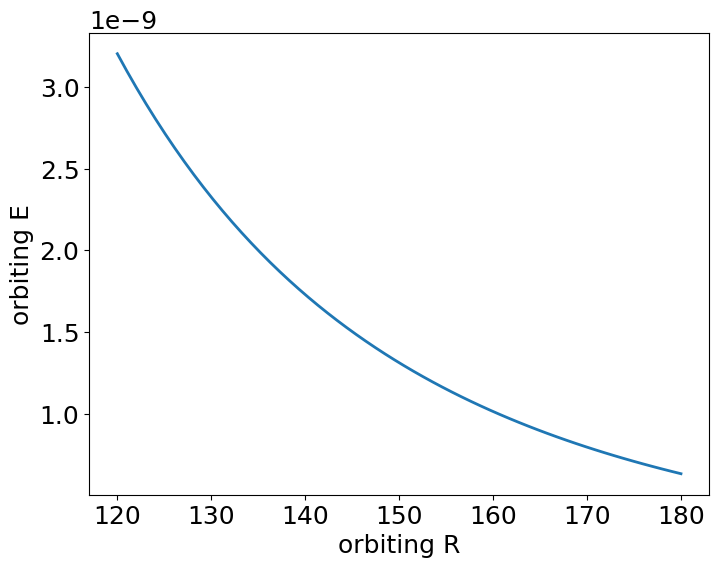

In [23]:
plt.plot(orbit_Rs, orbit_Es)
plt.xlabel("orbiting R")
plt.ylabel("orbiting E")

Text(0, 0.5, 'orbiting B')

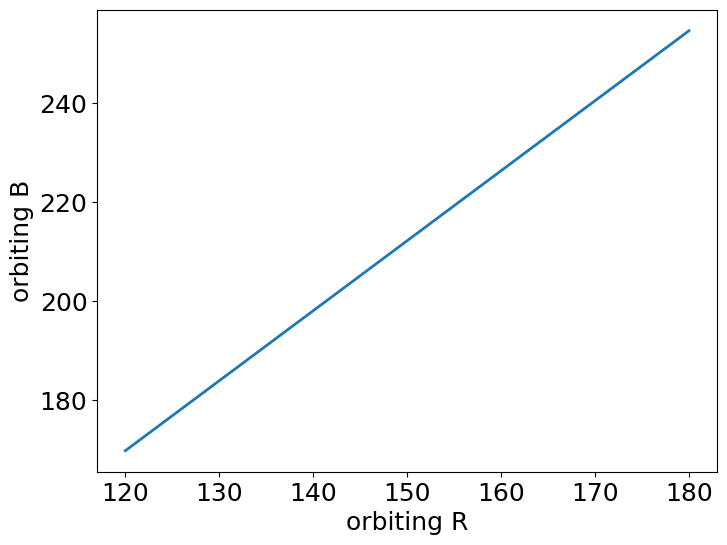

In [24]:
plt.plot(orbit_Rs, orbit_Bs)
plt.xlabel("orbiting R")
plt.ylabel("orbiting B")

In [25]:
def find_energy_decrease_index(orbit_list):
    '''This function looks through the list of orbiting parameters (E, b, r) starting
    at the end of the list (largest r) and working backward (towards smaller r.) It returns
    the first indx where the energy at that indx is bigger than the energy at indx - 1.'''
    for indx in range(len(orbit_list) - 1, 0, -1):
        curr_energy = orbit_list[indx][0]
        next_energy = orbit_list[indx - 1][0]
        if next_energy < curr_energy:
            return indx
    return float('nan')

In [26]:
def find_energy_max(potential, deriv_potential, r_interval, abs_tol = 10**(-6)):
    '''This function ...'''
    def objective(r):
        return - orbiting_params(r, potential, deriv_potential)[0]

    max_info = minimize_scalar(objective, 
                               bounds=r_interval, 
                               method='bounded', 
                               options = {'xatol' : abs_tol})
    return max_info.x

In [27]:
def find_energy_value(target_energy, potential, deriv_potential, r_interval, abs_tol = 10**(-6)):
    '''This function ...'''

    def f(r):
        orbit_energy = orbiting_params(r, potential, deriv_potential)[0]
        return target_energy - orbit_energy

    root_info = root_scalar(f, bracket=r_interval, xtol=abs_tol)
    return root_info.root

In [28]:
def find_rm_from_E_b(E, b, r_interval, vf, abs_tol = 10**(-6)):
    '''This function ...'''

    def f(r):
        return E - vf(r) - E * b**2 / r**2

    root_info = root_scalar(f, bracket=r_interval, xtol=abs_tol)
    return root_info.root

In [29]:
find_rm_from_E_b(1.0 * 10**(-9), 160.5481614632529, (5, 6), vf)

5.85237675705824

In [30]:
find_energy_value(1.0 * 10**(-9), vf, vd, (100, 200), abs_tol=10**(-8))

160.54816146328787

In [31]:
orbiting_params(160.54816146328787, vf, vd)

(9.999999999991282e-10, 227.04938735544718, 160.54816146328787)

In [32]:
b = impact_param_from_separation(160.54816146328787, 1e-9, vf)

In [33]:
b * np.sqrt(2) / 2

160.5481614632529

In [34]:
orbs = orbiting_list(vf, vd, vd2, 7, 45, 0.1)

testing 380 r values


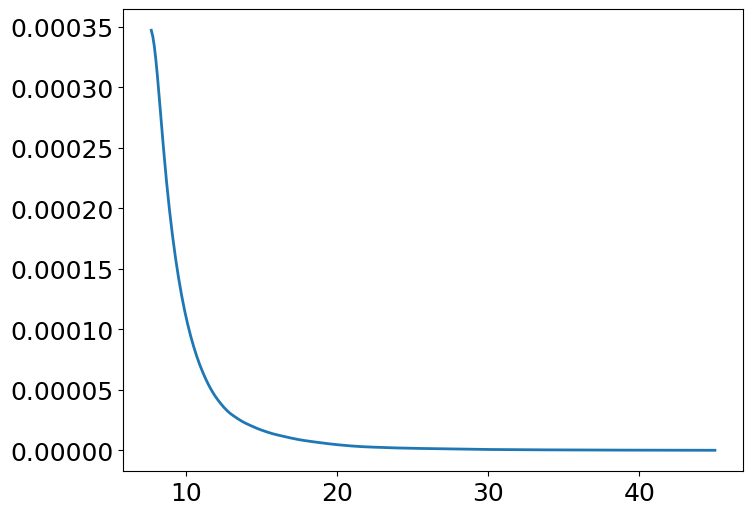

In [35]:
orbs_energies = [E for E, _, _ in orbs]
orbs_seps = [r for _, _, r in orbs]
plt.plot(orbs_seps, orbs_energies)

In [36]:
# For testing purposes, lets create a local max in orbiting param list E vs R func
start_indx = 40
end_indx = 60
energy_1 = orbs[start_indx][0]
energy_2 = orbs[end_indx][0]
offset = energy_1 - energy_2
assert offset > 0
for indx in range(end_indx, len(orbs)):
    new_energy = orbs[indx][0] + offset
    orbs[indx] = (new_energy, orbs[indx][1], orbs[indx][2])

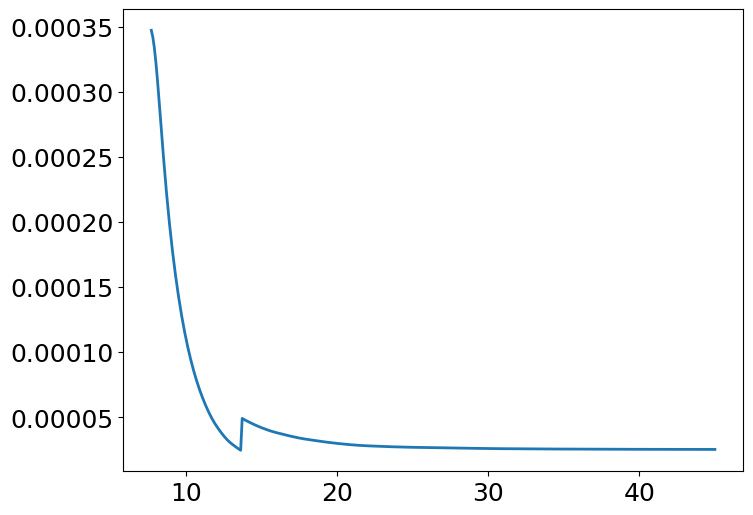

In [37]:
orbs_energies = [E for E, _, _ in orbs]
orbs_seps = [r for _, _, r in orbs]
plt.plot(orbs_seps, orbs_energies)

In [38]:
find_energy_decrease_index(orbs)

60

In [39]:
print(orbs[59])
print(orbs[60])
print(orbs[61])

(2.474129320352906e-05, 18.807442089475988, 13.617414248021108)
(4.9239880755205524e-05, 18.942206714459434, 13.717678100263852)
(4.8546995942341705e-05, 19.074516573056044, 13.817941952506597)


## TO DO: Create function that calls find_orbiting,find_energy_decrease, find_energy_decrease_precisely, find_energy_value_precisely and returns an interpolated mapping each energy to a separation.

### We want to write a function to compute the deflection angle

$$ \Huge \chi(\epsilon, b) = \pi - 2b \Huge \int_{r_m}^{\infty} \frac{1}{r^2 \sqrt{1 - \frac{b^2}{r^2} - \frac{V(r)}{\epsilon}}} \,dr$$

### Next we change variables using
$$ \Huge r = \frac{b}{w} \qquad dr = - b \frac{dw}{w^2}$$
### which gives us


$$ \Huge \chi(\epsilon, b) = \pi - 2 \int_{0}^{b/r_m} \frac{1}{\sqrt{1 - w^2 - \frac{V(b/w)}{\epsilon}}} \,dw$$

In [40]:
def deflection(epsilon, b, rm, potential, num_pts=500):
    w_vals = np.linspace(1.0/num_pts, b / rm, num_pts)
    # print(w_vals)
    root_insides = [1 - w**2 - potential(b/w)/epsilon for w in w_vals]
    if min(root_insides) < 0.0:
        assert False, "error: value under root is negative"
    integrand_vals = [2 / np.sqrt(1 - w**2 - potential(b/w)/epsilon) for w in w_vals]

    # TO DO: Rework integral below to use curtis-clenshaw
    return np.pi - np.trapz(integrand_vals, w_vals)

$$\Huge Q^{(\ell)}(\epsilon) = C_\ell \int_0^\infty \left[ 1 - \cos^\ell(\chi(\epsilon, b)\right]b\mkern1mu db$$
## where
$$\Huge C_\ell = \left[ 1 + \frac{1 + (-1)^\ell}{2 (\ell + 1)} \right]^{-1} $$
## or equivalently
$$\Huge C_\ell = \begin{cases}
1 & \text{if } \ell \mbox{ is odd} \\ \frac{\ell + 1}{\ell + 2} & \text{if } \ell \mbox{ is even.}
\end{cases}$$

In [41]:
def C_ell(ell):
    # TO DO: Documentation for this function
    if ell % 2 == 1:
        return 1
    else:
        return (ell + 1)/(ell + 2)

## To do this integral we split it into two pieces:

$$\Huge \int_0^1  \left[ 1 - \cos^\ell(\chi(\epsilon, b)\right]b\mkern1mu db + \int_1^\infty  \left[ 1 - \cos^\ell(\chi(\epsilon, b)\right]b\mkern1mu db$$

## Then, we change variables in the second integral:

$$ \Huge  b = \frac{1}{x} \qquad db = - \frac{1}{x^2}\,dx$$

## which turns the second integral into

$$\Huge \int_0^1  \left[ 1 - \cos^\ell\left(\chi\left(\epsilon,\frac{1}{x}\right)\right)\right]\frac{1}{x^3}\mkern1mu dx$$

In [42]:
def cross_section(ell, epsilon, potential, rm, num_pts=500):
    # create list of chi values
    b_vals = np.linspace(1.0/num_pts, 1, num_pts)
    chi_vals = [deflection(epsilon, b, rm, potential, num_pts) for b in b_vals]
    
    # first_integrand_values = 

    # TO DO: Use curtis-clenshaw method to calculate integrals
    
    return chi_vals

In [43]:
# seps = np.linspace(2.5, 60, 200)
# angle = 80

# vf = create_extrapolated_potential(distances_given[angle], energies_given[angle], long_range_pow)
# vd = create_derivative_potential(distances_given[angle], energies_given[angle], long_range_pow)
# vd2 = create_second_derivative_potential(distances_given[angle], energies_given[angle], long_range_pow)

# vals = [(r, vf(r), vd(r), vd2(r)) for r in seps]

# # plt.plot(seps, vals)

In [44]:
func = lambda x0,x1,x2,x3 : x0 + np.sin(x1)*x2 + x3**2
x0_range = (0,1)
x1_range = (0,2)
x2_range = (-3, 1)
x3_range = (-1, 1)

In [45]:
(val, err) = nquad(func, [x0_range, x1_range, x2_range, x3_range], opts = [{}, {}, {}, {}])

In [46]:
print(f"value={val},  error={err}")

value=2.004158640956194,  error=8.203861990868376e-14


In [47]:
f = lambda x: x**2
print(quad(f, 0, 1, full_output=1, weight='cos', wvar=10))

(-0.07009549944868729, 0.0, {'neval': 25, 'last': 0, 'iord': array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int32), 'alist': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'blist': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'rlist': array([-0.0700955,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.  